# Factor Analysis sur BFI (Big Five Inventory)

**Objectif**: extraire des facteurs latents sur les 25 items du BFI avec une approche EFA (Exploratory Factor Analysis), puis évaluer la qualité du modèle.

- Dataset: BFI (`psych::bfi`, 2800 participants, 25 items + démographie)
- Prétraitement: recodage des items inversés, suppression des valeurs manquantes
- Modèle: `FactorAnalyzer` avec rotation `varimax`
- Évaluation: KMO, Bartlett, variance expliquée, communalités, résidu de corrélation (RMSR), structure simple

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

pd.set_option("display.float_format", "{:.3f}".format)

In [4]:
# 1) Chargement des données et préparation
url = "https://vincentarelbundock.github.io/Rdatasets/csv/psych/bfi.csv"
raw = pd.read_csv(url, index_col=0)

item_columns = [
    "A1", "A2", "A3", "A4", "A5",
    "C1", "C2", "C3", "C4", "C5",
    "E1", "E2", "E3", "E4", "E5",
    "N1", "N2", "N3", "N4", "N5",
    "O1", "O2", "O3", "O4", "O5",
]
reverse_items = ["A1", "C4", "C5", "E1", "E2", "O2", "O5"]

items = raw.loc[:, item_columns].apply(pd.to_numeric, errors="coerce").copy()
for col in reverse_items:
    items[col] = 7 - items[col]

data = items.dropna().astype(float)

print(f"Shape brut: {raw.shape}")
print(f"Rows conservées après nettoyage: {len(data)} / {len(items)}")
print("Colonnes utilisées:", list(data.columns))

Shape brut: (2800, 28)
Rows conservées après nettoyage: 2436 / 2800
Colonnes utilisées: ['A1', 'A2', 'A3', 'A4', 'A5', 'C1', 'C2', 'C3', 'C4', 'C5', 'E1', 'E2', 'E3', 'E4', 'E5', 'N1', 'N2', 'N3', 'N4', 'N5', 'O1', 'O2', 'O3', 'O4', 'O5']


## Diagnostic de factorabilité

Avant d'entraîner le modèle, on vérifie que la structure de corrélation est compatible avec une analyse factorielle.

- `KMO` élevé (souvent > 0.7) = bonne adéquation échantillon/corrélations
- `Bartlett` significatif (p < 0.05) = matrice de corrélation non identité
- `Scree plot` = aide au choix du nombre de facteurs

In [5]:
# 2) Tests KMO / Bartlett + eigenvalues
corr = data.corr()
eigenvalues = np.linalg.eigvalsh(corr.values)[::-1]

kmo_items, kmo_overall = calculate_kmo(data)
chi_square, p_value = calculate_bartlett_sphericity(data)
dof = data.shape[1] * (data.shape[1] - 1) / 2

print("Top 10 eigenvalues:", np.round(eigenvalues[:10], 3))
print(f"KMO global: {kmo_overall:.3f}")
print("KMO par item:")
print(pd.Series(kmo_items, index=data.columns).sort_values().round(3))
print(f"Bartlett: chi2={chi_square:.1f}, dof={int(dof)}, p={p_value:.3e}")

Top 10 eigenvalues: [5.134 2.752 2.143 1.852 1.548 1.074 0.84  0.799 0.719 0.688]
KMO global: 0.849
KMO par item:
A1   0.754
O5   0.762
O4   0.770
N1   0.779
O2   0.780
N2   0.780
C2   0.796
C4   0.827
A2   0.836
E1   0.838
C1   0.843
O3   0.844
C3   0.852
O1   0.859
N5   0.860
N3   0.862
C5   0.864
A3   0.870
E4   0.877
A4   0.878
E2   0.884
N4   0.885
E5   0.893
E3   0.897
A5   0.904
dtype: float64
Bartlett: chi2=18146.1, dof=300, p=0.000e+00


## Entraînement du modèle factoriel

Ici on fixe `n_factors=5` (structure Big Five attendue) et on applique une rotation `varimax` pour faciliter l'interprétation.

In [6]:
# 3) Fit Factor Analysis (5 facteurs) + tableaux d'interprétation
factor_names = ["Extraversion", "Neuroticism", "Conscientiousness", "Openness", "Agreeableness"]

fa = FactorAnalyzer(n_factors=5, method="principal", rotation="varimax")
fa.fit(data)

loadings = pd.DataFrame(fa.loadings_, index=data.columns, columns=factor_names)
for col in loadings.columns:
    anchor = loadings[col].abs().idxmax()
    if loadings.loc[anchor, col] < 0:
        loadings[col] *= -1

communalities = pd.Series(fa.get_communalities(), index=data.columns, name="Communality")

var_ss, var_prop, var_cum = fa.get_factor_variance()
variance_df = pd.DataFrame(
    {
        "SS Loadings": var_ss,
        "Proportion Var": var_prop,
        "Cumulative Var": var_cum,
    },
    index=factor_names,
)

print("Rotated factor loadings:")
display(loadings.round(3))

print("Top 5 items par facteur:")
for col in loadings.columns:
    top_idx = loadings[col].abs().sort_values(ascending=False).head(5).index
    top_df = pd.DataFrame(
        {
            "loading": loadings.loc[top_idx, col].round(3),
            "abs_loading": loadings.loc[top_idx, col].abs().round(3),
        }
    ).sort_values("abs_loading", ascending=False)
    print(f"\n{col}")
    display(top_df)

print("Communalities:")
display(communalities.sort_values(ascending=False).round(3))

print("Variance expliquée par facteur:")
display(variance_df.round(3))

Rotated factor loadings:


,Extraversion,Neuroticism,Conscientiousness,Openness,Agreeableness
A1,-0.136,-0.147,-0.072,0.120,0.638
A2,0.220,0.034,0.130,0.057,0.716
A3,0.348,0.009,0.099,0.043,0.688
A4,0.210,-0.068,0.256,-0.170,0.530
A5,0.436,-0.129,0.075,0.048,0.571
C1,0.073,0.031,0.654,0.221,0.015
C2,0.038,0.115,0.738,0.099,0.096
C3,0.003,-0.019,0.679,-0.039,0.119
C4,0.043,-0.266,0.692,0.111,0.046
C5,0.173,-0.321,0.627,-0.064,0.038


Top 5 items par facteur:

Extraversion


,loading,abs_loading
E2,0.722,0.722
E4,0.700,0.700
E1,0.679,0.679
E3,0.626,0.626
E5,0.586,0.586



Neuroticism


...

,loading,abs_loading
A2,0.716,0.716
A3,0.688,0.688
A1,0.638,0.638
A5,0.571,0.571
A4,0.530,0.530


Communalities:


N1   0.710
N2   0.670
N3   0.636
E4   0.610
E2   0.608
A3   0.606
N4   0.587
A2   0.582
C2   0.579
C4   0.566
O3   0.561
A5   0.541
C5   0.532
E3   0.532
E5   0.506
C1   0.483
N5   0.482
E1   0.478
C3   0.477
O5   0.473
A1   0.467
O1   0.443
O4   0.440
O2   0.436
A4   0.424
Name: Communality, dtype: float64

Variance expliquée par facteur:


,SS Loadings,Proportion Var,Cumulative Var
Extraversion,3.104,0.124,0.124
Neuroticism,3.185,0.127,0.252
Conscientiousness,2.619,0.105,0.356
Openness,2.148,0.086,0.442
Agreeableness,2.374,0.095,0.537


## Évaluation des performances du modèle

En non supervisé, on ne parle pas d'accuracy de classe. On évalue la **qualité de la structure factorielle** avec:

- **Adéquation des données**: KMO, Bartlett
- **Qualité d'ajustement**: RMSR sur la matrice de corrélation
- **Qualité de représentation**: variance expliquée cumulée, communalités
- **Interprétabilité**: structure simple (loading principal fort, cross-loadings faibles)

In [7]:
# 4) Métriques d'évaluation de la Factor Analysis
R = data.corr().values
L = fa.loadings_
psi = fa.get_uniquenesses()
R_hat = L @ L.T + np.diag(psi)

residual = R - R_hat
off_diag_mask = ~np.eye(R.shape[0], dtype=bool)
rmsr = float(np.sqrt(np.mean(residual[off_diag_mask] ** 2)))

primary_abs = loadings.abs().max(axis=1)
second_abs = loadings.abs().apply(lambda r: r.nlargest(2).iloc[-1], axis=1)

simple_structure_ratio = float(((primary_abs >= 0.40) & (second_abs < 0.30)).mean())

eval_summary = pd.Series(
    {
        "KMO overall": float(kmo_overall),
        "Bartlett p-value": float(p_value),
        "Total variance explained": float(var_cum[-1]),
        "Mean communality": float(communalities.mean()),
        "Min communality": float(communalities.min()),
        "RMSR (off-diagonal)": rmsr,
        "Simple structure ratio": simple_structure_ratio,
    },
    name="FA evaluation",
)

print("Résumé des métriques:")
display(eval_summary.round(4))

print("\nRègles de lecture rapides:")
print("- KMO > 0.7: généralement acceptable")
print("- Bartlett p < 0.05: la factorisation est justifiée")
print("- RMSR plus faible: meilleure reproduction des corrélations")
print("- Communalités: idéalement pas trop faibles (ex: > 0.2)")
print("- Simple structure ratio élevé: facteurs plus interprétables")

Résumé des métriques:


KMO overall                0.849
Bartlett p-value           0.000
Total variance explained   0.537
Mean communality           0.537
Min communality            0.424
RMSR (off-diagonal)        0.056
Simple structure ratio     0.760
Name: FA evaluation, dtype: float64


Règles de lecture rapides:
- KMO > 0.7: généralement acceptable
- Bartlett p < 0.05: la factorisation est justifiée
- RMSR plus faible: meilleure reproduction des corrélations
- Communalités: idéalement pas trop faibles (ex: > 0.2)
- Simple structure ratio élevé: facteurs plus interprétables


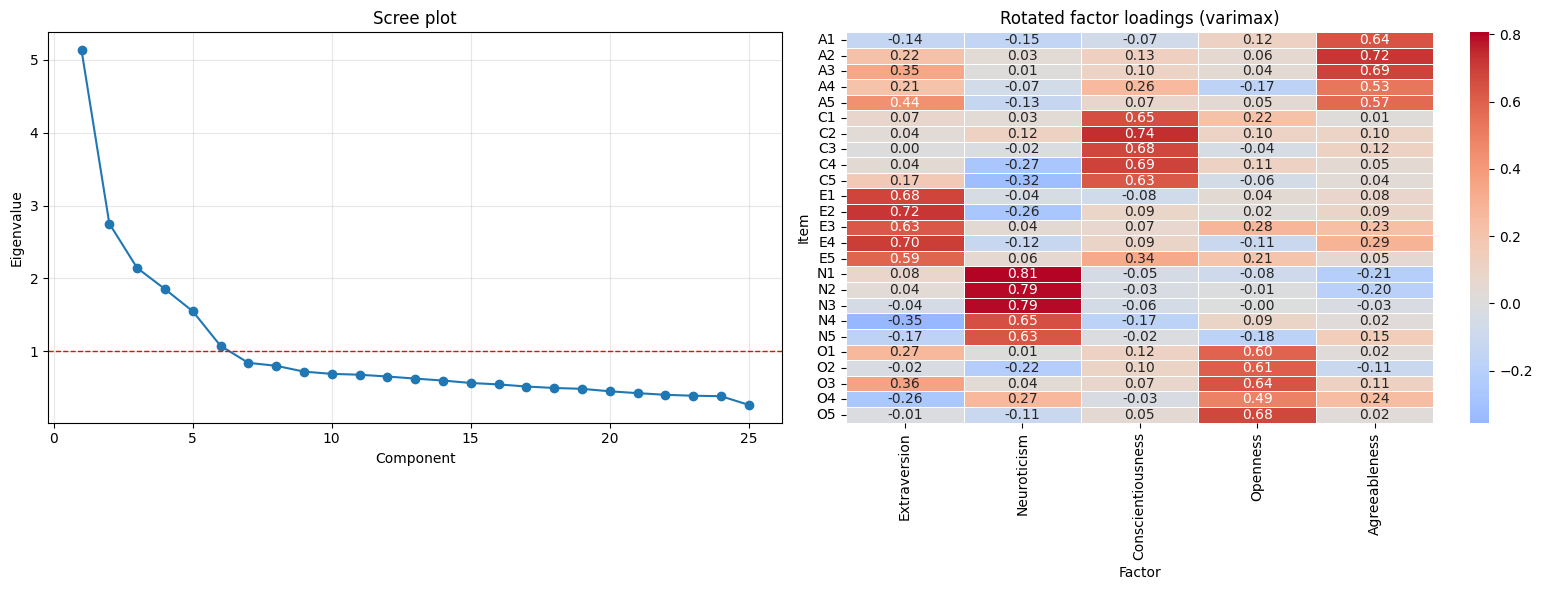

In [8]:
# 5) Visualisations (scree + heatmap des loadings)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(range(1, len(eigenvalues) + 1), eigenvalues, marker="o")
axes[0].axhline(1.0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Scree plot")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Eigenvalue")
axes[0].grid(alpha=0.3)

sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, ax=axes[1])
axes[1].set_title("Rotated factor loadings (varimax)")
axes[1].set_xlabel("Factor")
axes[1].set_ylabel("Item")

plt.tight_layout()
plt.show()